# MILO

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
    
    library(miloR)
    library(patchwork)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
source(paste0(main, "mapping_functions.R"))


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots




In [3]:
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
mapping_dir = paste0(main, '07_atlas_mapping/')
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [4]:
colData(sce) <- meta %>% tibble::column_to_rownames("cell") %>% DataFrame

In [5]:
pca = read.csv(paste0(main, '06_batch_correct/PCA_corrected.csv'))

In [6]:
rownames(pca) = pca[,1]
pca = pca[,-1]

In [7]:
# subset = sample(1:nrow(meta), 5000)
# sce = sce[,subset]

In [8]:
umap_mapped = colData(sce)[,c('umapX.mapped', 'umapY.mapped')]
reducedDims(sce) <- list(pca.corrected=pca, umap_mapped=umap_mapped)

In [9]:
embryo_data = sce

In [10]:
reducedDim(embryo_data, "pca.corrected") = as.matrix(reducedDim(embryo_data, "pca.corrected"))

In [138]:
# embryo_data <- embryo_data[,apply(reducedDim(embryo_data, "pca.corrected"), 1, function(x) !all(is.na(x)))]
# embryo_data <- runUMAP(embryo_data, dimred = "pca.corrected", name = 'umap')

# Run MILO

In [11]:
embryo_milo <- Milo(embryo_data)
embryo_milo

class: Milo 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(21): barcode stage ... umapX.mapped umapY.mapped
reducedDimNames(2): pca.corrected umap_mapped
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [12]:
embryo_milo <- buildGraph(embryo_milo, k = 30, d = 30, reduced.dim = "pca.corrected")

Constructing kNN graph with k:30



In [13]:
# lower prop for larger datasets
embryo_milo <- makeNhoods(embryo_milo, prop = 0.05, k = 30, d=30, refined = TRUE, reduced_dims = "pca.corrected")

Checking valid object



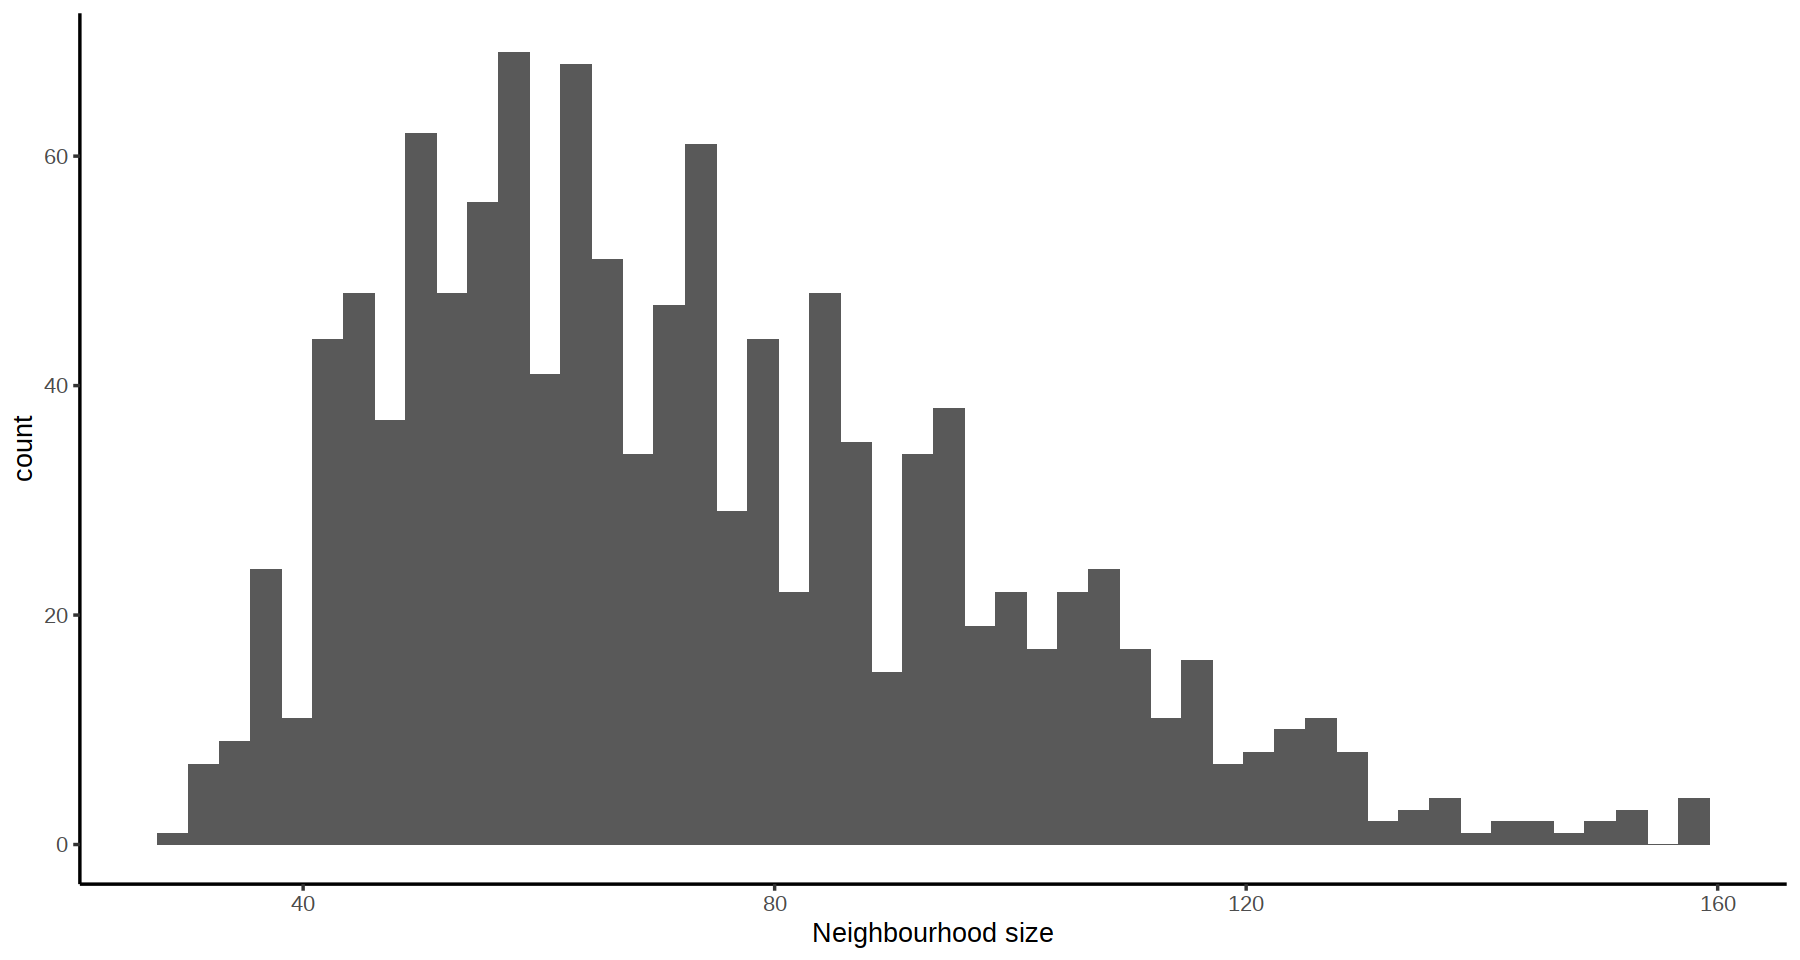

In [14]:
plotNhoodSizeHist(embryo_milo)

In [15]:
embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample")

Checking meta.data validity

Counting cells in neighbourhoods



In [16]:
embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "tdTom")]

## Convert batch info from integer to factor

embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample

In [17]:
embryo_milo <- calcNhoodDistance(embryo_milo, d=30, reduced.dim = "pca.corrected")

In [57]:
# design = what to test for, can correct for another variable as well
da_results <- testNhoods(embryo_milo, design = ~ tdTom, design.df = embryo_design, reduced.dim="pca.corrected")
head(da_results)

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1.088642,10.185362,2.794284,0.1064657302,0.133248863,1,0.1326793326
2,-7.129991,10.032072,17.329430,0.0019455453,0.003756375,2,0.0036437242
3,-1.953620,10.015066,5.899052,0.0223893537,0.032657950,3,0.0323230412
4,-2.028003,10.214860,11.482897,0.0022258326,0.004208985,4,0.0040924567
5,-1.451589,9.885625,4.961652,0.0346838251,0.049155918,5,0.0487125610
6,2.939633,10.080987,17.336544,0.0002993222,0.000736935,6,0.0007050217


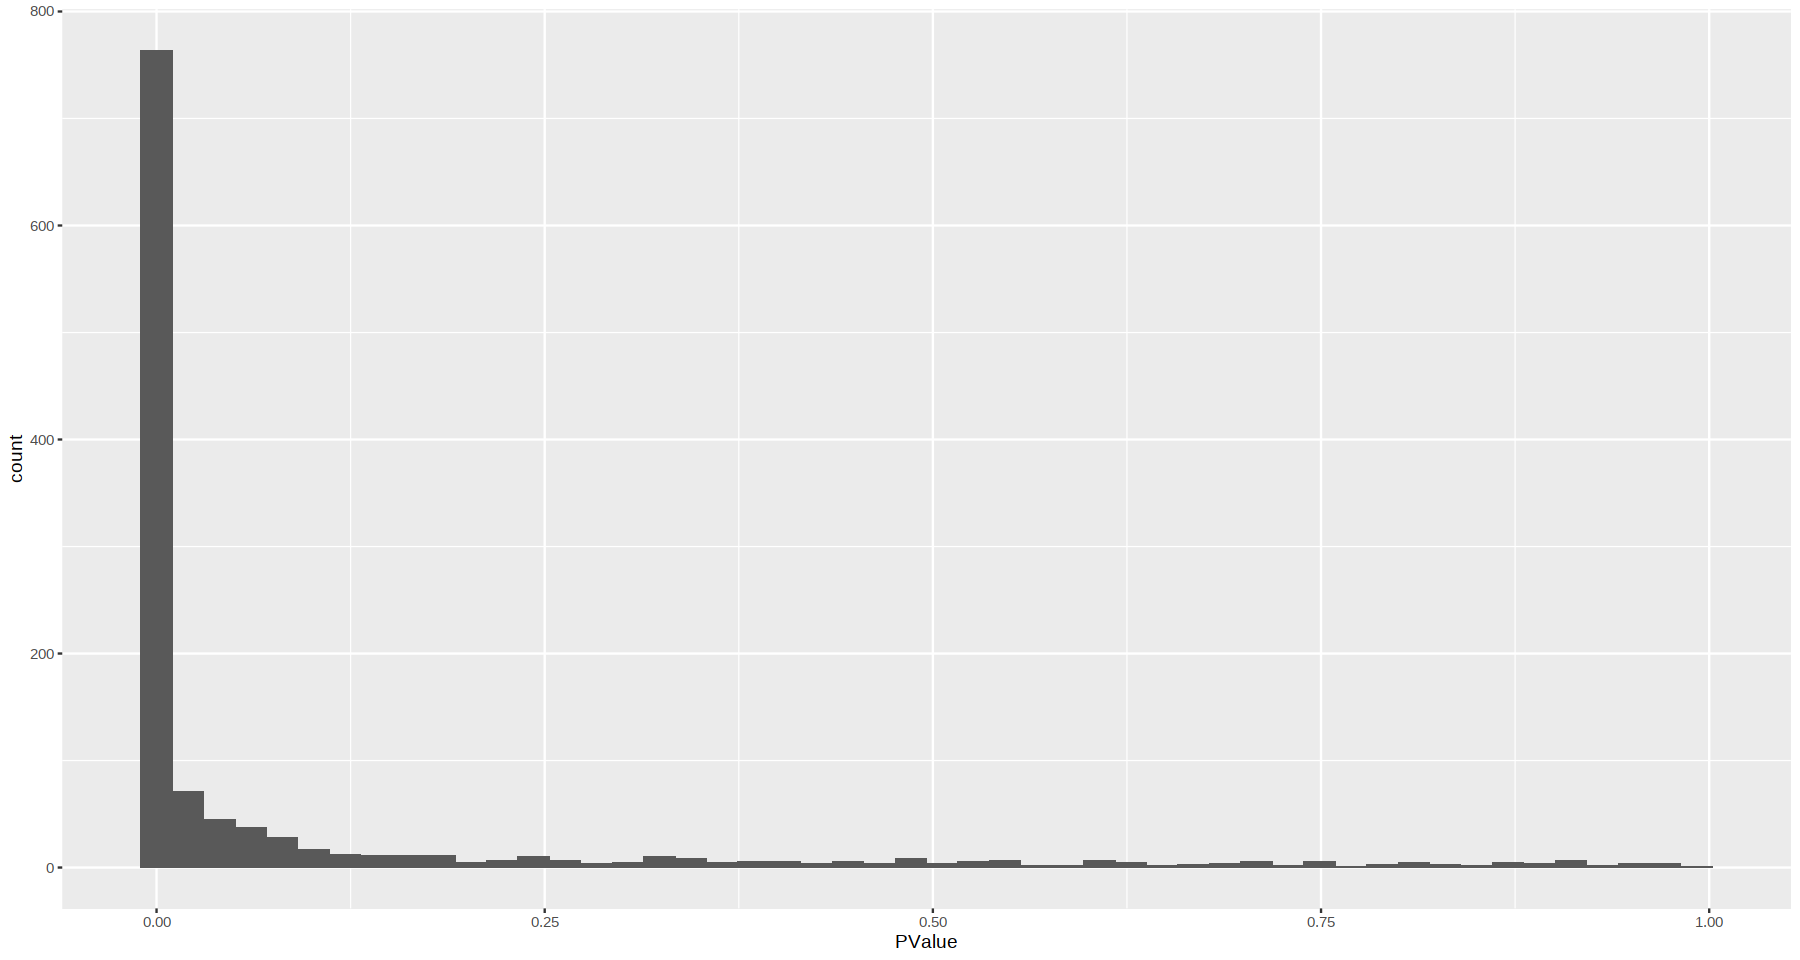

In [19]:
ggplot(da_results, aes(PValue)) + geom_histogram(bins=50)

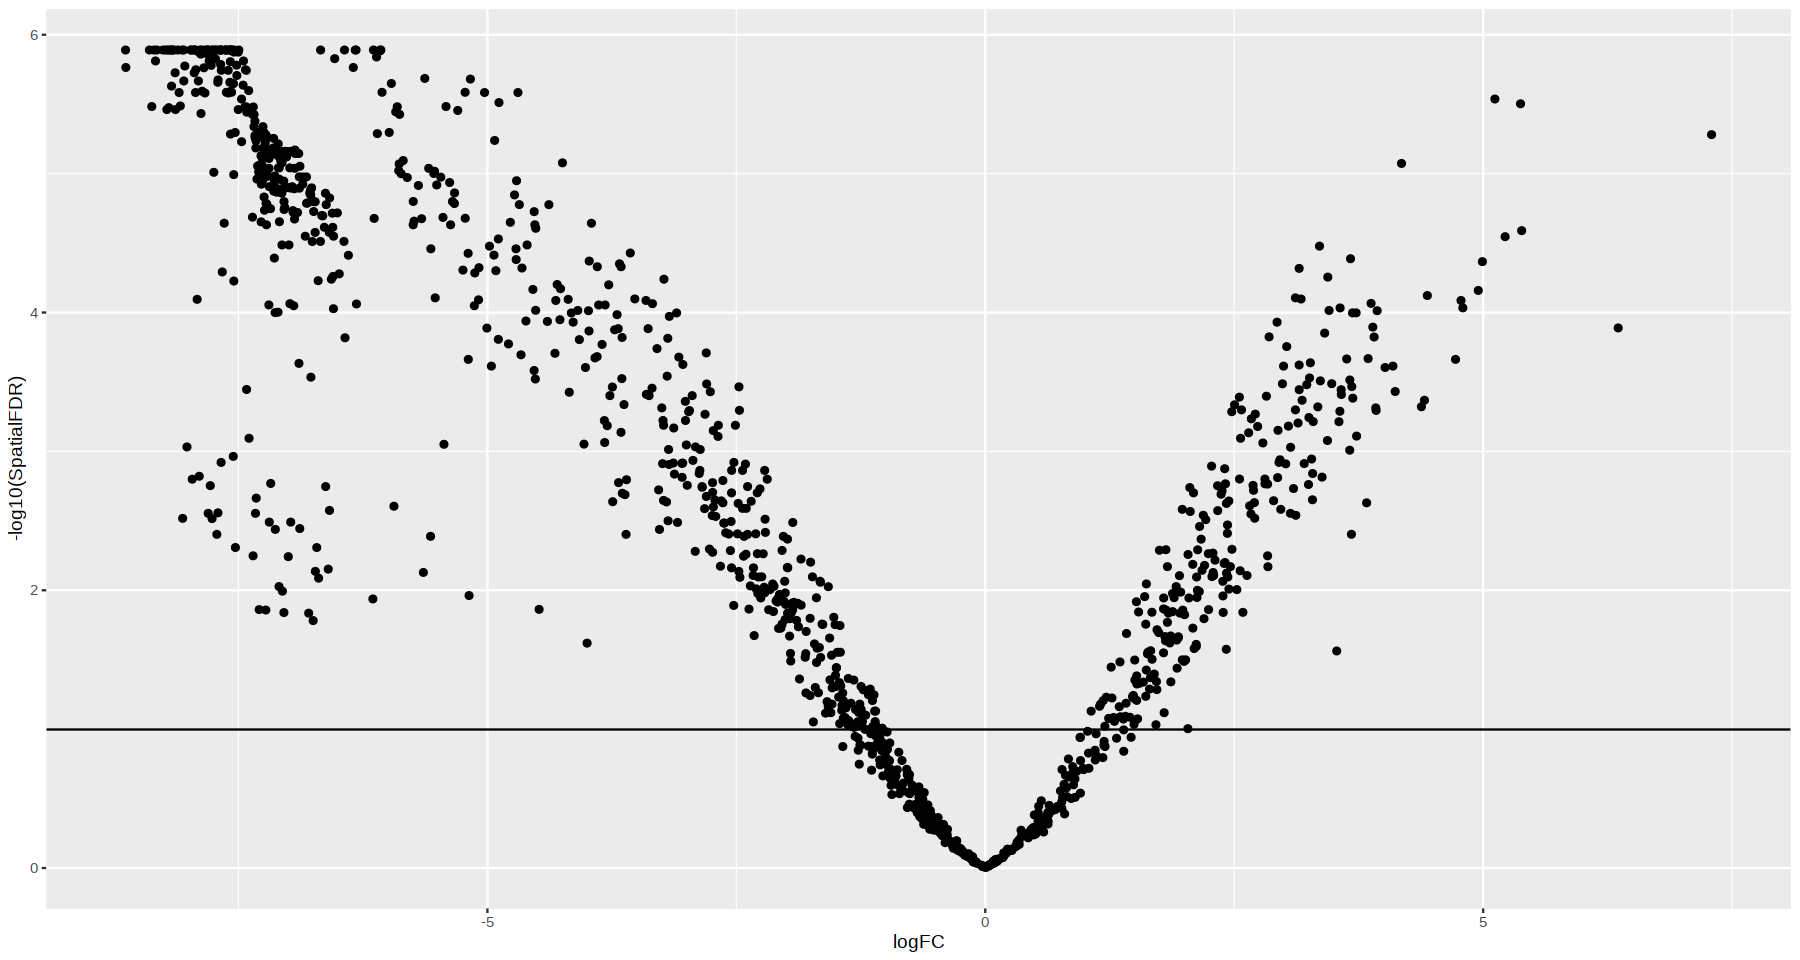

In [20]:
ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
  geom_point() +
  geom_hline(yintercept = 1) ## Mark significance threshold (10% FDR)

In [21]:
options(repr.plot.width=15, repr.plot.height=8)

In [58]:
da_results <- annotateNhoods(embryo_milo, da_results, coldata_col = "celltype.mapped")
head(da_results)

Converting celltype.mapped to factor...



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype.mapped,celltype.mapped_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,-1.088642,10.185362,2.794284,0.1064657302,0.133248863,1,0.1326793326,Rostral neurectoderm,0.8433735
2,-7.129991,10.032072,17.329430,0.0019455453,0.003756375,2,0.0036437242,ExE ectoderm,0.9855072
3,-1.953620,10.015066,5.899052,0.0223893537,0.032657950,3,0.0323230412,Intermediate mesoderm,0.6250000
4,-2.028003,10.214860,11.482897,0.0022258326,0.004208985,4,0.0040924567,Rostral neurectoderm,0.8933333
5,-1.451589,9.885625,4.961652,0.0346838251,0.049155918,5,0.0487125610,Surface ectoderm,0.9491525
6,2.939633,10.080987,17.336544,0.0002993222,0.000736935,6,0.0007050217,Allantois,0.8518519


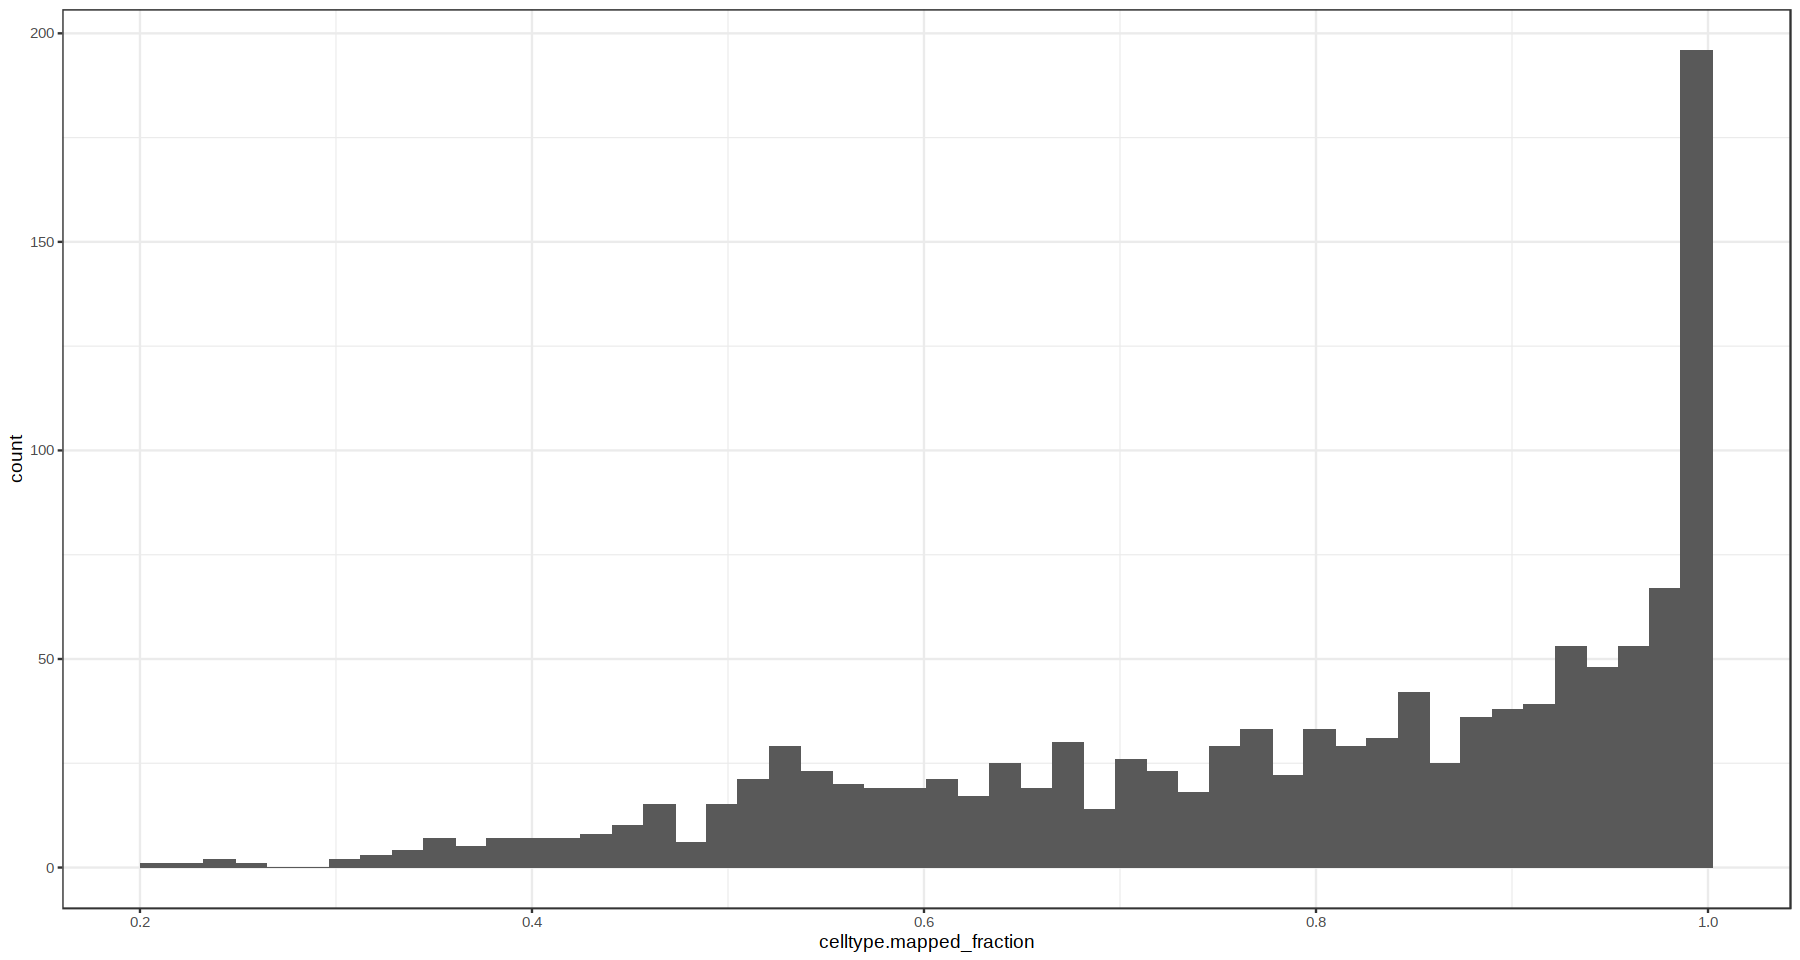

In [23]:
ggplot(da_results, aes(celltype.mapped_fraction)) + geom_histogram(bins=50) + theme_bw()

In [59]:
da_results$celltype.mapped <- ifelse(da_results$celltype.mapped_fraction < 0.5, "Mixed", da_results$celltype.mapped)


Converting group.by to factor...



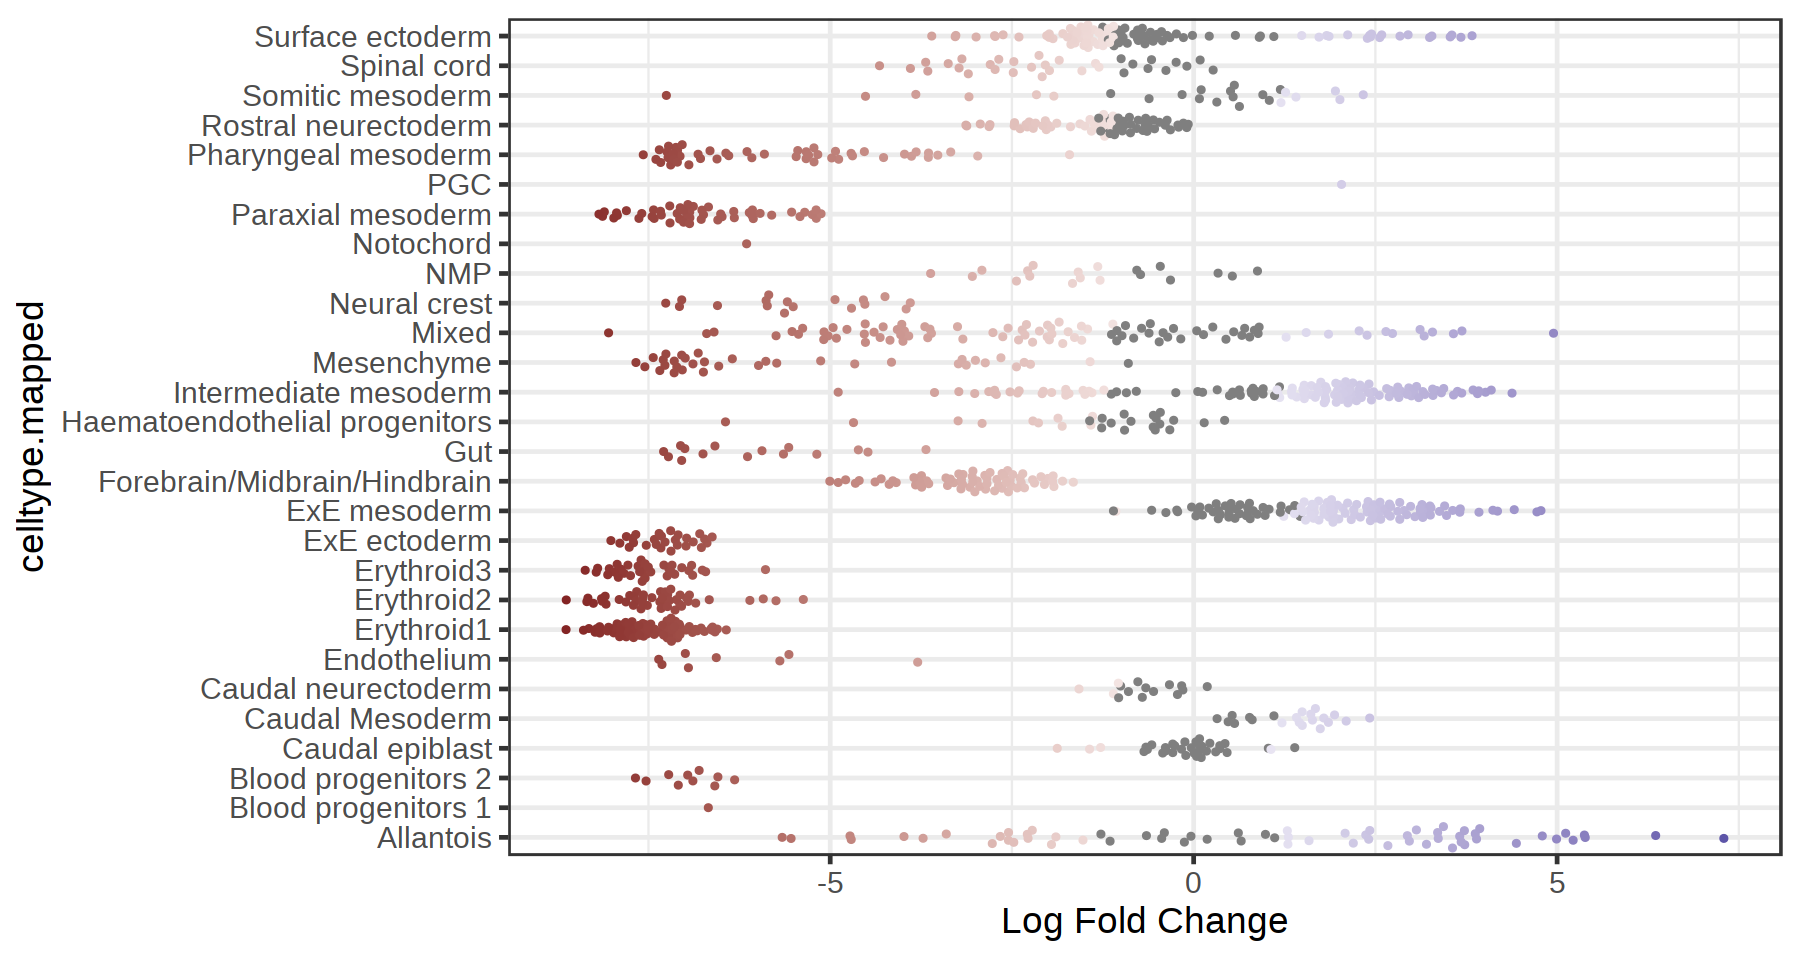

In [25]:
plotDAbeeswarm(da_results, group.by = "celltype.mapped")


In [28]:
embryo_milo <- buildNhoodGraph(embryo_milo)


Warning message in plotNhoodGraph(x, colour_by = res_column, ...):
“Coercing layout to matrix format”


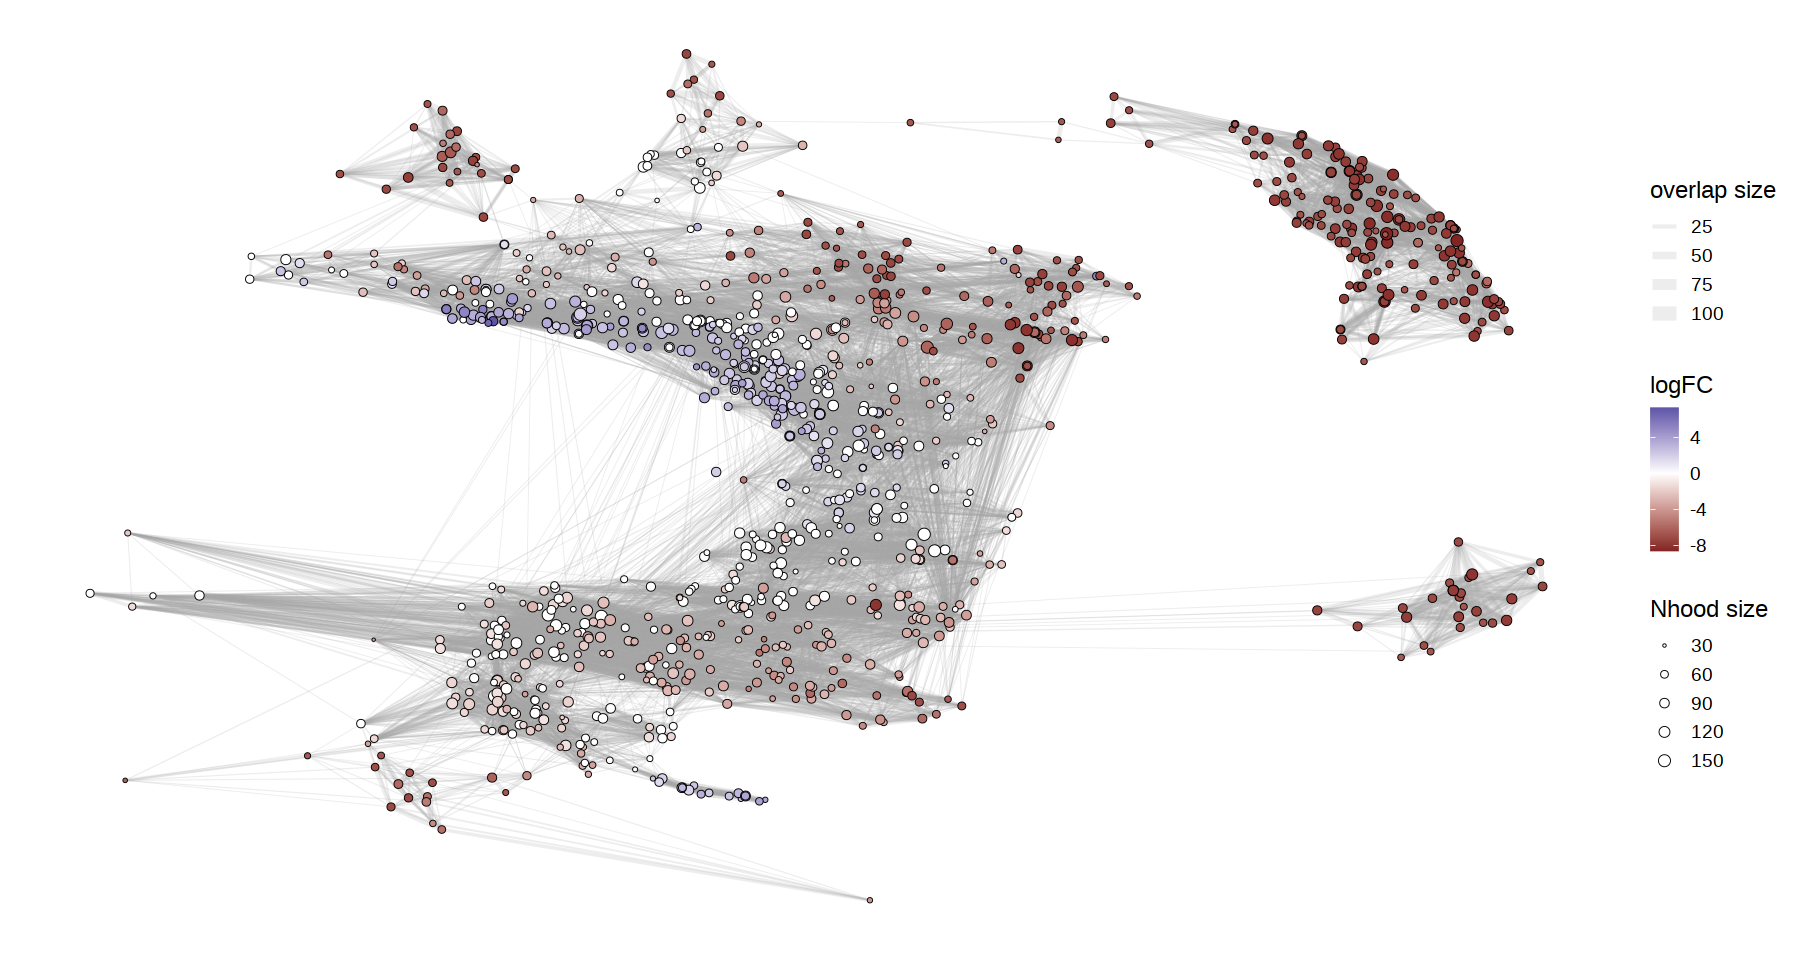

In [29]:

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap_mapped",alpha=0.1) 
nh_graph_pl

In [31]:
saveRDS(embryo_milo, file.path(main, 'milo_object.rds'))

In [32]:
fwrite(da_results, file.path(main, 'da_results.txt.gz'))

In [56]:
head(da_results)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype.mapped,celltype.mapped_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,-1.088642,10.185362,2.794284,0.1064657302,0.133248863,1,0.1326793326,NA,0.8433735
2,-7.129991,10.032072,17.329430,0.0019455453,0.003756375,2,0.0036437242,NA,0.9855072
3,-1.953620,10.015066,5.899052,0.0223893537,0.032657950,3,0.0323230412,NA,0.6250000
4,-2.028003,10.214860,11.482897,0.0022258326,0.004208985,4,0.0040924567,NA,0.8933333
5,-1.451589,9.885625,4.961652,0.0346838251,0.049155918,5,0.0487125610,NA,0.9491525
6,2.939633,10.080987,17.336544,0.0002993222,0.000736935,6,0.0007050217,NA,0.8518519


[1] "Allantois"                      "Blood progenitors 1"           
 [3] "Blood progenitors 2"            "Caudal epiblast"               
 [5] "Caudal Mesoderm"                "Caudal neurectoderm"           
 [7] "Endothelium"                    "Erythroid1"                    
 [9] "Erythroid2"                     "Erythroid3"                    
[11] "ExE ectoderm"                   "ExE mesoderm"                  
[13] "Forebrain/Midbrain/Hindbrain"   "Gut"                           
[15] "Haematoendothelial progenitors" "Intermediate mesoderm"         
[17] "Mesenchyme"                     "Mixed"                         
[19] "Neural crest"                   "NMP"                           
[21] "Notochord"                      "Paraxial mesoderm"             
[23] "PGC"                            "Pharyngeal mesoderm"           
[25] "Rostral neurectoderm"           "Somitic mesoderm"              
[27] "Spinal cord"                    "Surface ectoderm"

In [69]:
da_results$celltype.mapped = factor(da_results$celltype.mapped, levels = rev(unique(sort(da_results$celltype.mapped))))

In [73]:
p1 = plotDAbeeswarm(da_results, group.by = "celltype.mapped") + xlab('') + theme(axis.text=element_text(color='black'))

In [74]:
pdf(file.path(main, '/figures/MILO_beeswarm.pdf'), width=10, height=10)
    p1
dev.off()

png 
  2

In [75]:

pdf(file.path(main, '/figures/MILO_Nhood_graph.pdf'), width=10, height=10)
    nh_graph_pl
dev.off()

png 
  2